# Vehicle Maintenance Dataset Analysis

## Objective

This notebook presents the preprocessing and exploratory analysis of the Vehicle Maintenance dataset used in the **AutoIntel AI – Intelligent Vehicle Diagnosis and Maintenance Assistant** project.

The primary objective is to understand the dataset structure, assess its quality, perform necessary preprocessing, and prepare a clean dataset for subsequent feature engineering, SQL integration, and AI-based vehicle diagnosis.

The analysis carried out in this notebook serves as the foundation for developing an intelligent maintenance recommendation system capable of assisting users in diagnosing vehicle issues using historical maintenance records.

## Step 1 – Dataset Understanding

## Step 2 – Data Profiling

## Step 3 – Exploratory Data Analysis

## Step 4 – Data Cleaning

## Step 5 – SQL Dataset Preparation

In [9]:
from google.colab import files
import pandas as pd

# Upload CSV file
uploaded = files.upload()

Saving vehicle_maintenance_data.csv to vehicle_maintenance_data (1).csv


In [40]:
df = pd.read_csv("vehicle_maintenance_data.csv")
df.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,23-11-2023,24-06-2025,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,21-09-2023,04-06-2025,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,27-06-2023,27-04-2025,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,24-08-2023,05-11-2025,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,25-05-2023,14-09-2025,Third,16446,6,2,16.977483,Good,Good,Weak,1


In [12]:
df.shape

(50000, 20)

Which column uniquely identifies a vehicle?

In [13]:
df.columns

Index(['Vehicle_Model', 'Mileage', 'Maintenance_History', 'Reported_Issues',
       'Vehicle_Age', 'Fuel_Type', 'Transmission_Type', 'Engine_Size',
       'Odometer_Reading', 'Last_Service_Date', 'Warranty_Expiry_Date',
       'Owner_Type', 'Insurance_Premium', 'Service_History',
       'Accident_History', 'Fuel_Efficiency', 'Tire_Condition',
       'Brake_Condition', 'Battery_Status', 'Need_Maintenance'],
      dtype='object')

Answer:

The dataset does not contain a unique vehicle identifier. Each row represents a vehicle record, but no dedicated primary key is available.

Which columns represent dates?

Answer:

Last_Service_Date
Warranty_Expiry_Date

Which columns represent costs?

Answer:

Insurance_Premium

Which columns describe repairs/maintenance?

Answer:

Maintenance_History
Reported_Issues
Service_History
Tire_Condition
Brake_Condition
Battery_Status
Need_Maintenance

In [14]:
df.dtypes

,0
Vehicle_Model,object
Mileage,int64
Maintenance_History,object
Reported_Issues,int64
Vehicle_Age,int64
Fuel_Type,object
Transmission_Type,object
Engine_Size,int64
Odometer_Reading,int64
Last_Service_Date,object


Step 2 – Data Profiling

# Data Quality Assessment

Before conducting any analysis, the dataset is evaluated to identify potential data quality issues that may affect downstream processing and model performance.

The assessment focuses on:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Invalid or inconsistent entries
- Overall dataset integrity

Identifying these issues at an early stage ensures that the preprocessing pipeline produces a reliable and analysis-ready dataset.

In [15]:
df.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,23-11-2023,24-06-2025,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,21-09-2023,04-06-2025,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,27-06-2023,27-04-2025,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,24-08-2023,05-11-2025,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,25-05-2023,14-09-2025,Third,16446,6,2,16.977483,Good,Good,Weak,1


In [16]:
df.shape

(50000, 20)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_Model         50000 non-null  object 
 1   Mileage               50000 non-null  int64  
 2   Maintenance_History   50000 non-null  object 
 3   Reported_Issues       50000 non-null  int64  
 4   Vehicle_Age           50000 non-null  int64  
 5   Fuel_Type             50000 non-null  object 
 6   Transmission_Type     50000 non-null  object 
 7   Engine_Size           50000 non-null  int64  
 8   Odometer_Reading      50000 non-null  int64  
 9   Last_Service_Date     50000 non-null  object 
 10  Warranty_Expiry_Date  50000 non-null  object 
 11  Owner_Type            50000 non-null  object 
 12  Insurance_Premium     50000 non-null  int64  
 13  Service_History       50000 non-null  int64  
 14  Accident_History      50000 non-null  int64  
 15  Fuel_Efficiency    

In [18]:
df.describe()

,Mileage,Reported_Issues,Vehicle_Age,Engine_Size,Odometer_Reading,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Need_Maintenance
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,54931.232680,2.497420,5.492260,1556.292000,75551.187060,17465.340700,5.515560,1.50156,14.990323,0.809960
std,14401.912925,1.708781,2.875682,627.677218,43088.105658,7223.393401,2.874899,1.11951,2.885583,0.392336
min,30001.000000,0.000000,1.000000,800.000000,1001.000000,5000.000000,1.000000,0.00000,10.000098,0.000000
25%,42471.500000,1.000000,3.000000,1000.000000,38009.000000,11189.750000,3.000000,0.00000,12.489037,1.000000
50%,54810.000000,2.000000,5.000000,1500.000000,75598.500000,17477.500000,6.000000,2.00000,14.986352,1.000000
75%,67391.500000,4.000000,8.000000,2000.000000,112999.500000,23692.000000,8.000000,3.00000,17.474676,1.000000
max,80000.000000,5.000000,10.000000,2500.000000,149999.000000,30000.000000,10.000000,3.00000,19.999968,1.000000


In [19]:
df.isnull().sum()

,0
Vehicle_Model,0
Mileage,0
Maintenance_History,0
Reported_Issues,0
Vehicle_Age,0
Fuel_Type,0
Transmission_Type,0
Engine_Size,0
Odometer_Reading,0
Last_Service_Date,0


In [20]:
df.duplicated().sum()

np.int64(0)

Observations:

Dataset Shape:
The dataset contains 50,000 rows and 20 columns.

Dataset Information
Total entries: 50,000
Total columns: 20
Numeric columns: 10
Categorical (object) columns: 10
Memory usage: 7.6 MB

Summary Statistics
Average mileage is approximately 54,931 km.
Average vehicle age is about 5.49 years.
Average reported issues are 2.5 per vehicle.
Average insurance premium is approximately 17,465.
Vehicle ages range from 1 to 10 years.
Odometer readings range from 1,001 to 149,999 km.

Step 3: Exploratory Data Analysis (EDA)

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the underlying characteristics of the Vehicle Maintenance dataset.

The objective of this phase is to identify meaningful patterns, trends, anomalies, and relationships between variables that can support future predictive maintenance models and intelligent diagnosis.

The analysis includes both statistical summaries and graphical visualizations.

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

1. Which vehicle model appears most often?

In [21]:
df['Vehicle_Model'].value_counts()

,count
Vehicle_Model,
Bus,8414
Van,8400
SUV,8360
Truck,8328
Motorcycle,8295
Car,8203


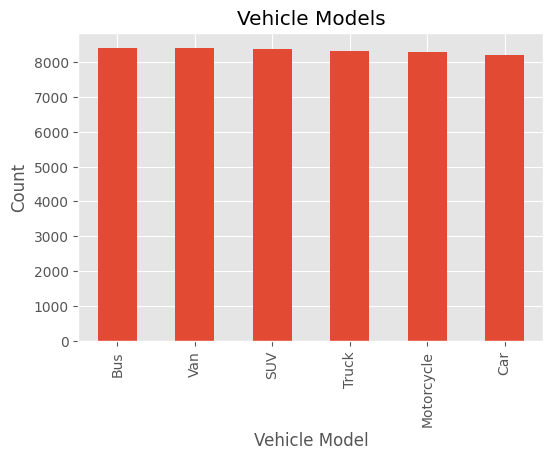

In [24]:
df['Vehicle_Model'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Vehicle Models")
plt.xlabel("Vehicle Model")
plt.ylabel("Count")
plt.show()

### Observations

- Vehicle records are distributed across multiple vehicle categories.
- The distribution is relatively balanced, reducing the likelihood of category bias during analysis.
- The dataset is suitable for comparative analysis across different vehicle models.

2. What is the average insurance premium?

In [25]:
df['Insurance_Premium'].mean()

np.float64(17465.3407)


3. Which maintenance history category appears most frequently?

In [26]:
df['Maintenance_History'].value_counts()

,count
Maintenance_History,
Average,16724
Good,16712
Poor,16564


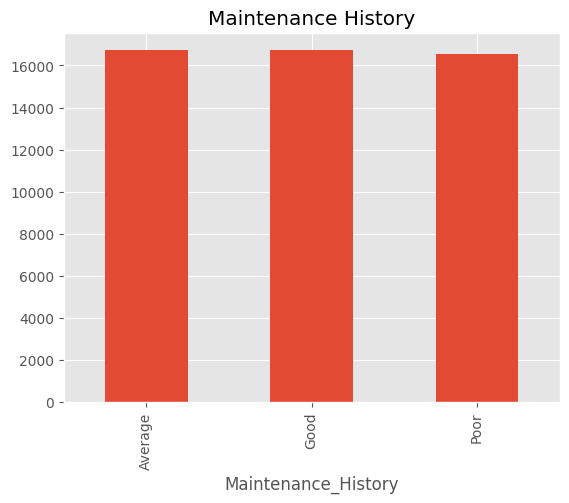

In [27]:
df['Maintenance_History'].value_counts().plot(kind='bar')
plt.title("Maintenance History")
plt.show()

4. Distribution of Mileage

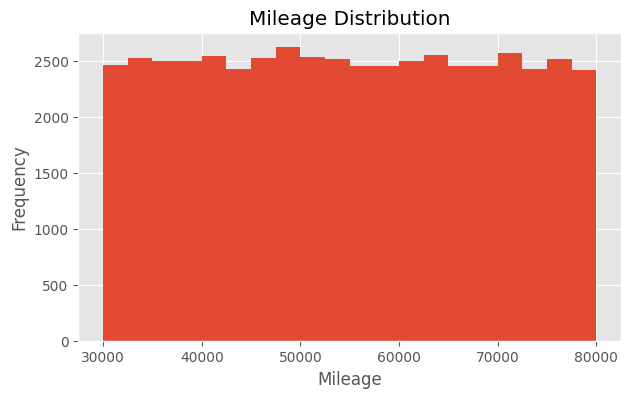

In [28]:
plt.figure(figsize=(7,4))
plt.hist(df['Mileage'], bins=20)
plt.title("Mileage Distribution")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()

### Observations

- Vehicle mileage spans a wide range, indicating different usage levels.
- Most vehicles fall within the mid-mileage range.
- Mileage is expected to be an important predictor for maintenance requirements.

5. Insurance Premium Distribution (Box Plot)

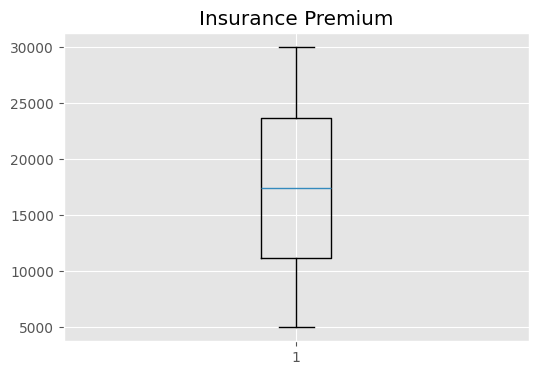

In [29]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Insurance_Premium'])
plt.title("Insurance Premium")
plt.show()

### Observations

- Insurance premiums show noticeable variation across vehicles.
- A small number of higher premium values appear as outliers.
- These values should be considered during future predictive modeling.

6. Fuel Type Distribution (Pie Chart)

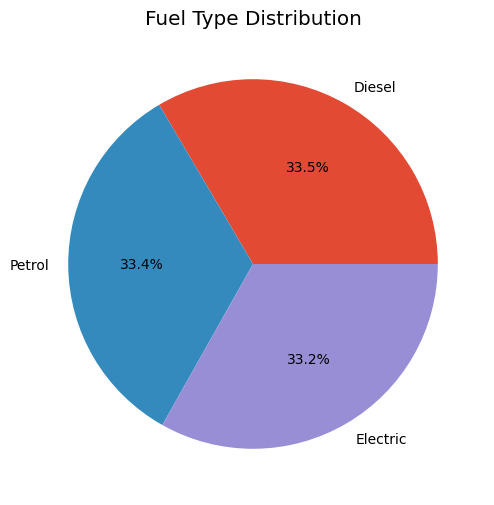

In [30]:
df['Fuel_Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.ylabel("")
plt.title("Fuel Type Distribution")
plt.show()

### Observations

- The dataset contains multiple fuel categories.
- Fuel types appear reasonably represented.
- Fuel type may influence maintenance frequency and repair cost.

Step 4: Data Cleaning

In [31]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [32]:
df.isnull().sum()

,0
Vehicle_Model,0
Mileage,0
Maintenance_History,0
Reported_Issues,0
Vehicle_Age,0
Fuel_Type,0
Transmission_Type,0
Engine_Size,0
Odometer_Reading,0
Last_Service_Date,0


In [33]:
df['Last_Service_Date'] = pd.to_datetime(df['Last_Service_Date'])
df['Warranty_Expiry_Date'] = pd.to_datetime(df['Warranty_Expiry_Date'])

/tmp/ipykernel_2298/1918479187.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Last_Service_Date'] = pd.to_datetime(df['Last_Service_Date'])
/tmp/ipykernel_2298/1918479187.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Warranty_Expiry_Date'] = pd.to_datetime(df['Warranty_Expiry_Date'])


In [34]:
df[['Last_Service_Date', 'Warranty_Expiry_Date']].dtypes

,0
Last_Service_Date,datetime64[ns]
Warranty_Expiry_Date,datetime64[ns]


In [35]:
df.columns = df.columns.str.lower()

In [36]:
df.columns

Index(['vehicle_model', 'mileage', 'maintenance_history', 'reported_issues',
       'vehicle_age', 'fuel_type', 'transmission_type', 'engine_size',
       'odometer_reading', 'last_service_date', 'warranty_expiry_date',
       'owner_type', 'insurance_premium', 'service_history',
       'accident_history', 'fuel_efficiency', 'tire_condition',
       'brake_condition', 'battery_status', 'need_maintenance'],
      dtype='object')

In [37]:
text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = df[col].str.strip().str.title()

In [39]:
df['vehicle_model'].unique()

array(['Truck', 'Van', 'Bus', 'Motorcycle', 'Suv', 'Car'], dtype=object)

In [38]:
df.to_csv("vehicle_maintenance_clean.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [41]:
df.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,23-11-2023,24-06-2025,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,21-09-2023,04-06-2025,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,27-06-2023,27-04-2025,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,24-08-2023,05-11-2025,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,25-05-2023,14-09-2025,Third,16446,6,2,16.977483,Good,Good,Weak,1


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_Model         50000 non-null  object 
 1   Mileage               50000 non-null  int64  
 2   Maintenance_History   50000 non-null  object 
 3   Reported_Issues       50000 non-null  int64  
 4   Vehicle_Age           50000 non-null  int64  
 5   Fuel_Type             50000 non-null  object 
 6   Transmission_Type     50000 non-null  object 
 7   Engine_Size           50000 non-null  int64  
 8   Odometer_Reading      50000 non-null  int64  
 9   Last_Service_Date     50000 non-null  object 
 10  Warranty_Expiry_Date  50000 non-null  object 
 11  Owner_Type            50000 non-null  object 
 12  Insurance_Premium     50000 non-null  int64  
 13  Service_History       50000 non-null  int64  
 14  Accident_History      50000 non-null  int64  
 15  Fuel_Efficiency    

In [43]:
print(df.shape)

(50000, 20)


In [44]:
df.dtypes

,0
Vehicle_Model,object
Mileage,int64
Maintenance_History,object
Reported_Issues,int64
Vehicle_Age,int64
Fuel_Type,object
Transmission_Type,object
Engine_Size,int64
Odometer_Reading,int64
Last_Service_Date,object


In [45]:
df.describe(include='all')

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
count,50000,50000.000000,50000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000,50000,50000,50000.000000,50000.000000,50000.00000,50000.000000,50000,50000,50000,50000.000000
unique,6,NaN,3,NaN,NaN,3,2,NaN,NaN,336,701,3,NaN,NaN,NaN,NaN,3,3,3,NaN
top,Bus,NaN,Average,NaN,NaN,Diesel,Manual,NaN,NaN,25-11-2023,16-09-2024,Second,NaN,NaN,NaN,NaN,New,Worn Out,New,NaN
freq,8414,NaN,16724,NaN,NaN,16738,25009,NaN,NaN,182,101,16875,NaN,NaN,NaN,NaN,16825,16685,16725,NaN
mean,NaN,54931.232680,NaN,2.497420,5.492260,NaN,NaN,1556.292000,75551.187060,NaN,NaN,NaN,17465.340700,5.515560,1.50156,14.990323,NaN,NaN,NaN,0.809960
std,NaN,14401.912925,NaN,1.708781,2.875682,NaN,NaN,627.677218,43088.105658,NaN,NaN,NaN,7223.393401,2.874899,1.11951,2.885583,NaN,NaN,NaN,0.392336
min,NaN,30001.000000,NaN,0.000000,1.000000,NaN,NaN,800.000000,1001.000000,NaN,NaN,NaN,5000.000000,1.000000,0.00000,10.000098,NaN,NaN,NaN,0.000000
25%,NaN,42471.500000,NaN,1.000000,3.000000,NaN,NaN,1000.000000,38009.000000,NaN,NaN,NaN,11189.750000,3.000000,0.00000,12.489037,NaN,NaN,NaN,1.000000
50%,NaN,54810.000000,NaN,2.000000,5.000000,NaN,NaN,1500.000000,75598.500000,NaN,NaN,NaN,17477.500000,6.000000,2.00000,14.986352,NaN,NaN,NaN,1.000000
75%,NaN,67391.500000,NaN,4.000000,8.000000,NaN,NaN,2000.000000,112999.500000,NaN,NaN,NaN,23692.000000,8.000000,3.00000,17.474676,NaN,NaN,NaN,1.000000


# SQL Dataset Preparation

The cleaned dataset has been prepared for integration with the project database.

The following preprocessing requirements have been satisfied:

- Standardized attribute names
- Consistent data types
- Removal of duplicate entries
- Structured categorical values
- Export in CSV format

The processed dataset can now be imported into SQLite or MySQL for integration with the AutoIntel AI application.

Observations

- No duplicate records were found.
- No missing values were present.
- Date columns were successfully converted to datetime format.
- Column names are now consistent.
- Text values are standardized.
- The cleaned dataset is ready for SQL integration and further analysis.

# Feature Engineering Plan (Week 2)

The next development phase focuses on generating meaningful features from the cleaned dataset that can enhance predictive analysis and intelligent vehicle diagnosis.

The planned engineered features include:

| Feature | Purpose |
|----------|---------|
| Vehicle Age | Estimate wear based on manufacturing year |
| Days Since Last Service | Measure maintenance intervals |
| Total Repairs | Identify frequently serviced vehicles |
| Average Repair Cost | Estimate long-term maintenance expense |
| Service Frequency | Determine maintenance patterns |
| Cost per Kilometer | Evaluate maintenance efficiency |
| Component Failure Count | Identify commonly failing components |
| Maintenance Risk Score | Overall vehicle maintenance indicator |

These engineered features will support machine learning models, similarity-based retrieval, and intelligent maintenance recommendations.

# Week 1 Summary

## Work Completed

The Week 1 objectives for the Vehicle Maintenance module have been successfully completed.

### Completed Tasks

- Vehicle Maintenance dataset analysis
- Data quality assessment
- Data preprocessing and cleaning
- Exploratory Data Analysis (EDA)
- Identification of key maintenance trends
- Preparation of SQL-compatible dataset
- Export of cleaned dataset

The processed dataset now provides a reliable foundation for feature engineering, database integration, and AI-powered vehicle diagnosis in the subsequent phases of the AutoIntel AI project.